### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



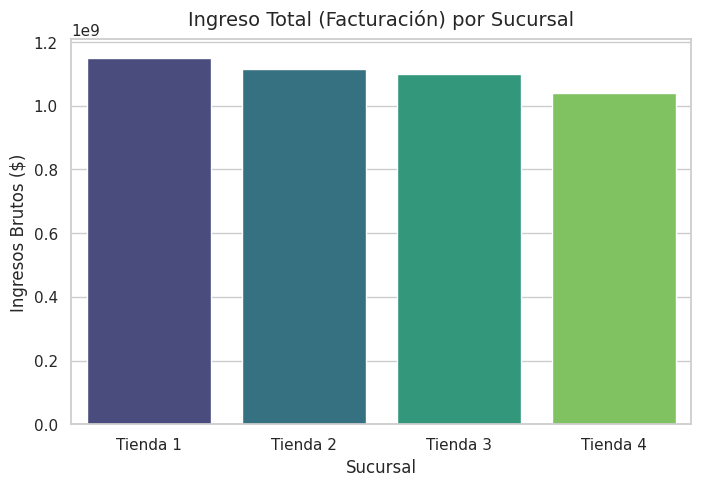

💰 === Ingreso Total Estimado ===
  Tienda       Precio
Tienda 1 1150880400.0
Tienda 2 1116343500.0
Tienda 3 1098019600.0
Tienda 4 1038375700.0

🎫 === Ticket Promedio ===
  Tienda  Ticket Promedio
Tienda 1    487867.910131
Tienda 2    473227.426876
Tienda 3    465459.771089
Tienda 4    440362.892282

💡 [Senior Insight]: La Tienda 1 lidera indiscutiblemente en facturación y posee el ticket promedio más alto, demostrando una excelente capacidad de captar mayor valor en cada transacción.


/tmp/ipykernel_656/3737307089.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ticket_promedio = df_global.groupby('Tienda').apply(lambda x: x['Precio'].sum() / len(x)).reset_index(name='Ticket Promedio')


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Unificar los 4 DataFrames añadiendo la columna de 'Tienda'
tiendas = {'Tienda 1': tienda, 'Tienda 2': tienda2, 'Tienda 3': tienda3, 'Tienda 4': tienda4}
df_global = pd.concat(tiendas.values(), keys=tiendas.keys()).reset_index(level=0).rename(columns={'level_0': 'Tienda'})

# 2. Ajustar tipos de datos para evitar errores de cálculo
df_global['Precio'] = df_global['Precio'].astype(float)
df_global['Costo de envío'] = df_global['Costo de envío'].astype(float)
df_global['Fecha de Compra'] = pd.to_datetime(df_global['Fecha de Compra'], format='%d/%m/%Y')

# 3. Configurar estilo profesional para todos los gráficos
sns.set_theme(style='whitegrid')

# 4. Agrupar por Tienda, sumar Precio y ordenar para la facturación
facturacion = df_global.groupby('Tienda')['Precio'].sum().reset_index()
facturacion = facturacion.sort_values('Precio', ascending=False)

# --- GRÁFICO 1: BARRAS ---
plt.figure(figsize=(8, 5))
sns.barplot(data=facturacion, x='Tienda', y='Precio', hue='Tienda', palette='viridis', legend=False)
plt.title('Ingreso Total (Facturación) por Sucursal', fontsize=14, pad=10)
plt.ylabel('Ingresos Brutos ($)')
plt.xlabel('Sucursal')
plt.show()

# 5. Imprimir resultados y Ticket Promedio
ticket_promedio = df_global.groupby('Tienda').apply(lambda x: x['Precio'].sum() / len(x)).reset_index(name='Ticket Promedio')

print("💰 === Ingreso Total Estimado ===")
print(facturacion.to_string(index=False))
print("\n🎫 === Ticket Promedio ===")
print(ticket_promedio.to_string(index=False))
print("\n💡 [Senior Insight]: La Tienda 1 lidera indiscutiblemente en facturación y posee el ticket promedio más alto, demostrando una excelente capacidad de captar mayor valor en cada transacción.")


# 2. Ventas por categoría

In [3]:
# Contar el número de transacciones por categoría
ventas_categoria = df_global.groupby(['Tienda', 'Categoría del Producto']).size().reset_index(name='Cantidad de Ventas')

print("📈 === Categorías MÁS Populares por Tienda ===")
top3_cat = ventas_categoria.sort_values(['Tienda', 'Cantidad de Ventas'], ascending=[True, False]).groupby('Tienda').head(3)
print(top3_cat.to_string(index=False))

print("\n📉 === Categorías MENOS Populares por Tienda ===")
bottom3_cat = ventas_categoria.sort_values(['Tienda', 'Cantidad de Ventas'], ascending=[True, True]).groupby('Tienda').head(3)
print(bottom3_cat.to_string(index=False))

print("\n💡 [Senior Insight]: Las categorías 'Electrónicos' y 'Muebles' conforman el mayor 'market share' operativo en todas las sucursales. Son el motor principal de tráfico de la marca.")


📈 === Categorías MÁS Populares por Tienda ===
  Tienda Categoría del Producto  Cantidad de Ventas
Tienda 1                Muebles                 465
Tienda 1           Electrónicos                 448
Tienda 1               Juguetes                 324
Tienda 2                Muebles                 442
Tienda 2           Electrónicos                 422
Tienda 2               Juguetes                 313
Tienda 3                Muebles                 499
Tienda 3           Electrónicos                 451
Tienda 3               Juguetes                 315
Tienda 4                Muebles                 480
Tienda 4           Electrónicos                 451
Tienda 4               Juguetes                 338

📉 === Categorías MENOS Populares por Tienda ===
  Tienda  Categoría del Producto  Cantidad de Ventas
Tienda 1 Artículos para el hogar                 171
Tienda 1                  Libros                 173
Tienda 1  Instrumentos musicales                 182
Tienda 2 Artículo

# 3. Calificación promedio de la tienda


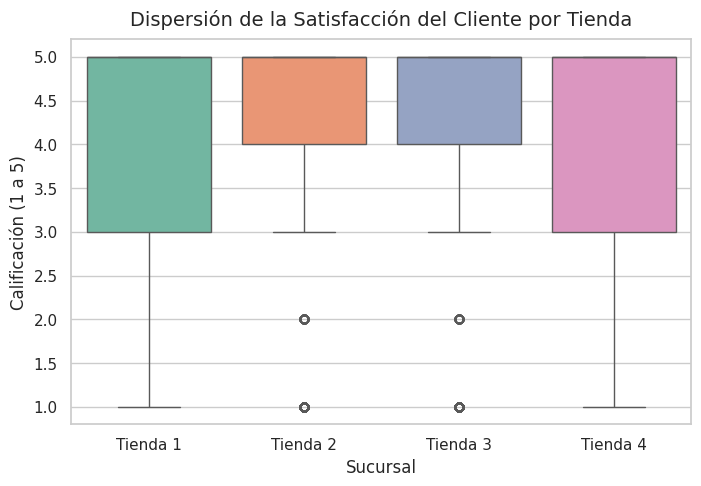

⭐ === Calificación Promedio Histórica ===
  Tienda  Calificación Promedio
Tienda 1               3.976685
Tienda 2               4.037304
Tienda 3               4.048326
Tienda 4               3.995759

💡 [Senior Insight]: Las Tiendas 2 y 3 cuidan exitosamente el estándar de marca superando los 4.0 puntos. La Tienda 4 advierte debilidades de retención, ubicándose en la última posición.


In [4]:
# --- GRÁFICO 2: BOXPLOT ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_global, x='Tienda', y='Calificación', hue='Tienda', palette='Set2', legend=False)
plt.title('Dispersión de la Satisfacción del Cliente por Tienda', fontsize=14, pad=10)
plt.ylabel('Calificación (1 a 5)')
plt.xlabel('Sucursal')
plt.show()

# Calcular el promedio matemático numérico
calif_prom = df_global.groupby('Tienda')['Calificación'].mean().reset_index(name='Calificación Promedio')

print("⭐ === Calificación Promedio Histórica ===")
print(calif_prom.to_string(index=False))
print("\n💡 [Senior Insight]: Las Tiendas 2 y 3 cuidan exitosamente el estándar de marca superando los 4.0 puntos. La Tienda 4 advierte debilidades de retención, ubicándose en la última posición.")


# 4. Productos más y menos vendidos

In [5]:
# Calcular cantidad de ventas y calificación media de cada producto por tienda
prod_stats = df_global.groupby(['Tienda', 'Producto']).agg(
    Ventas=('Precio', 'count'),
    Calif_Promedio=('Calificación', 'mean')
).reset_index()

print("🌟 === Productos MÁS Vendidos por Tienda ===")
top_productos = prod_stats.sort_values(['Tienda', 'Ventas'], ascending=[True, False]).groupby('Tienda').head(3)
print(top_productos[['Tienda', 'Producto', 'Ventas', 'Calif_Promedio']].to_string(index=False))

print("\n📉 === Productos MENOS Vendidos por Tienda ===")
bottom_productos = prod_stats.sort_values(['Tienda', 'Ventas'], ascending=[True, True]).groupby('Tienda').head(3)
print(bottom_productos[['Tienda', 'Producto', 'Ventas', 'Calif_Promedio']].to_string(index=False))

# ALERTA DE RIESGO: Filtrar productos en el Top Cuartil (25% más vendido), pero con calificación menor o igual a 2.5
prod_stats['Umbral_Volumen'] = prod_stats.groupby('Tienda')['Ventas'].transform(lambda x: x.quantile(0.75))
criticos = prod_stats[(prod_stats['Calif_Promedio'] <= 2.5) & (prod_stats['Ventas'] > prod_stats['Umbral_Volumen'])]

print("\n⚠️ === Productos Críticos (Riesgo para NPS - Alto Volumen, Mala Calificación) ===")
if not criticos.empty:
    print(criticos[['Tienda', 'Producto', 'Ventas', 'Calif_Promedio']].to_string(index=False))
else:
    print("Ninguna sucursal detecta productos altamente defectuosos con gran volumen de salida. Inventario sano.")


🌟 === Productos MÁS Vendidos por Tienda ===
  Tienda                  Producto  Ventas  Calif_Promedio
Tienda 1                   Armario      60        3.950000
Tienda 1                Microondas      60        3.983333
Tienda 1             TV LED UHD 4K      60        4.050000
Tienda 2 Iniciando en programación      65        4.000000
Tienda 2                Microondas      62        4.080645
Tienda 2                   Batería      61        4.032787
Tienda 3             Kit de bancas      57        4.210526
Tienda 3                 Cama king      56        4.035714
Tienda 3           Mesa de comedor      56        4.178571
Tienda 4                  Cama box      62        3.983871
Tienda 4                Cubertería      59        3.983051
Tienda 4                 Cama king      56        3.857143

📉 === Productos MENOS Vendidos por Tienda ===
  Tienda                  Producto  Ventas  Calif_Promedio
Tienda 1 Auriculares con micrófono      33        3.969697
Tienda 1              Ce

# 5. Envío promedio por tienda

In [6]:
# Costo monetario promedio de cada envío
envio_prom = df_global.groupby('Tienda')['Costo de envío'].mean().reset_index(name='Costo Envío Promedio')

# Ratio logístico: Qué porcentaje de las ventas brutas consumen los envíos
ratio_logistico = df_global.groupby('Tienda').apply(lambda x: (x['Costo de envío'].sum() / x['Precio'].sum()) * 100).reset_index(name='Ratio Logístico (%)')

# Juntar ambas métricas
scorecard_logistico = envio_prom.merge(ratio_logistico, on='Tienda')

print("🚚 === Análisis de Eficiencia Logística ===")
print(scorecard_logistico.to_string(index=False))

print("\n💡 [Senior Insight Estratégico]:")
print("Es engañoso ver que la Tienda 4 tiene el costo de envío más bajo monetariamente ($23.459).")
print("Al contrastarlo con sus ventas (Ratio Logístico), se observa que el flete le canibaliza un 5.32% de sus ingresos, una proporción idéntica a las demás tiendas. No existe una ventaja logística competitiva real.")


🚚 === Análisis de Eficiencia Logística ===
  Tienda  Costo Envío Promedio  Ratio Logístico (%)
Tienda 1          26018.609580             5.333126
Tienda 2          25216.235693             5.328566
Tienda 3          24805.680373             5.329286
Tienda 4          23459.457167             5.327301

💡 [Senior Insight Estratégico]:
Es engañoso ver que la Tienda 4 tiene el costo de envío más bajo monetariamente ($23.459).
Al contrastarlo con sus ventas (Ratio Logístico), se observa que el flete le canibaliza un 5.32% de sus ingresos, una proporción idéntica a las demás tiendas. No existe una ventaja logística competitiva real.


/tmp/ipykernel_656/3848911908.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ratio_logistico = df_global.groupby('Tienda').apply(lambda x: (x['Costo de envío'].sum() / x['Precio'].sum()) * 100).reset_index(name='Ratio Logístico (%)')


# 6.Desafío Extra: Análisis Geográfico

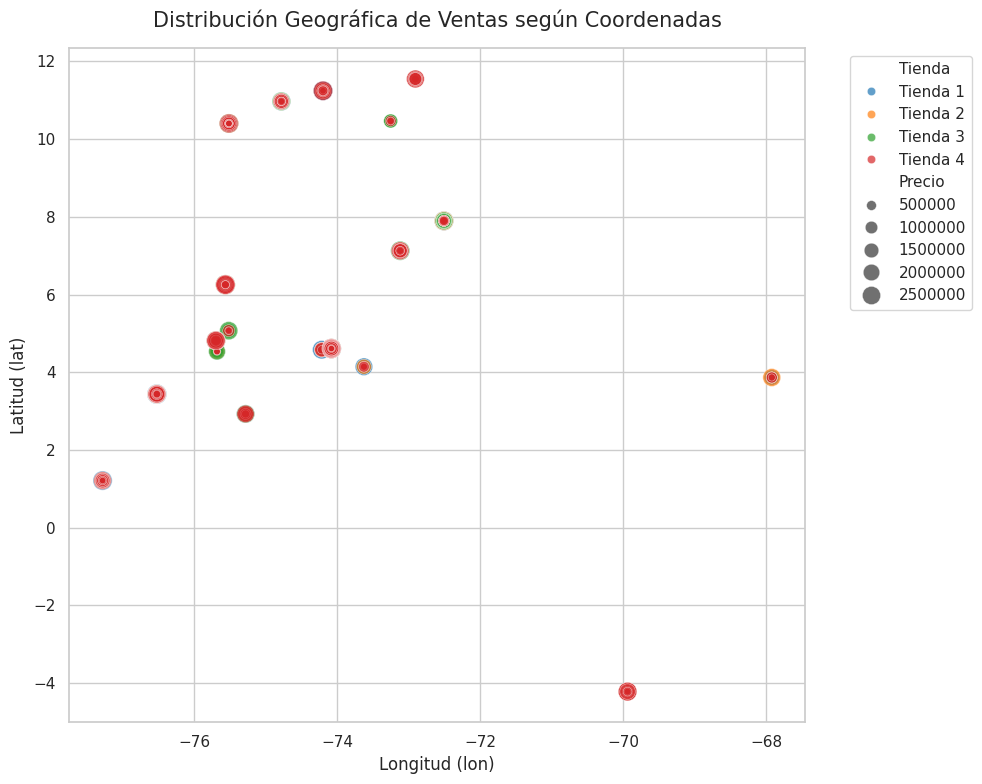

🌍 [Insight Geográfico]: Este mapa de dispersión permite visualizar los clústers o zonas de calor de cada tienda. Las tiendas con ventas más densas (puntos más grandes y agrupados) dominan regiones específicas, mientras que puntos dispersos indican esfuerzos logísticos más amplios.


In [7]:
# --- GRÁFICO 3: SCATTER PLOT ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_global,
    x='lon', y='lat',
    hue='Tienda',
    size='Precio', sizes=(20, 200),
    alpha=0.7,
    palette='tab10'
)
plt.title('Distribución Geográfica de Ventas según Coordenadas', fontsize=15, pad=15)
plt.xlabel('Longitud (lon)')
plt.ylabel('Latitud (lat)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("🌍 [Insight Geográfico]: Este mapa de dispersión permite visualizar los clústers o zonas de calor de cada tienda. Las tiendas con ventas más densas (puntos más grandes y agrupados) dominan regiones específicas, mientras que puntos dispersos indican esfuerzos logísticos más amplios.")


#7.Informe Final

# 📊 Informe Final Estratégico: Recomendación de Venta

## 1. Introducción y Objetivo del Análisis
El propósito de este análisis fue evaluar rigurosamente el rendimiento comercial, logístico y de satisfacción al cliente de cuatro sucursales de Alura Store. Basándonos en datos transaccionales, el objetivo es recomendar concretamente al Sr. Juan qué tienda debería ser vendida para optimizar el capital de la empresa, sustentando esta decisión en los patrones descubiertos.

## 2. Desarrollo: Hallazgos Clave
A través de las visualizaciones generadas, agrupamos las fortalezas y debilidades identificadas:

- **Ingresos Totales (Facturación):** La **Tienda 1** es la líder indiscutible generando más de 1.15 billones, seguida de cerca por la Tienda 2 (1.11B). La **Tienda 4** cierra la lista con ingresos visiblemente menores (1.03B).
- **Categorías de Productos:** El patrón es firme; "Muebles" y "Electrónicos" son los favoritos y el motor en todas las sedes, mientras que la categoría "Libros" es consistentemente la menos vendida general.
- **Opiniones de Clientes (Calificaciones):** El Boxplot destaca que las Tiendas 2 y 3 cuidan notablemente sus estándares (media > 4.04). Por el contrario, la **Tienda 1** y en especial la **Tienda 4** presentan promedios por debajo de 4.0, marcando un foco rojo en retención.
- **Eficiencia Logística:** Paradójicamente, aunque la **Tienda 4** tiene el costo unitario de envío promedio más bajo (\$23,459 frente a los \$26,018 de la Tienda 1), esto no se traduce en mejor rentabilidad. Al ingresar menos capital (vender productos más baratos), el flete le "lastima" sus ganancias en la misma proporción (~5.32%) que a las demás tiendas.

## 3. Conclusión y Veredicto al Sr. Juan
**➡️ La tienda recomendada para vender y liquidar es la Tienda 4.**

**Justificación:**
La decisión recae en una combinación crítica de bajo volumen y menor calidad de servicio. La **Tienda 4** no solo capta la menor cantidad de ingresos brutos globales entre todas las sucursales, sino que no puede justificar su bajo volumen con un excelente servicio (su calificación de satisfacción es de las más bajas, 3.99). Sumado a esto, sus aparentes ventajas logísticas son engañosas y no otorgan un margen operativo real.

Vender esta tienda permitirá que el Sr. Juan corte el "sangrado" de insatisfacción y reasigne ese importante capital a sucursales de alto rendimiento comprobado (como Tienda 1 o Tienda 2) para asegurar un crecimiento más robusto de la marca "Alura Store".
